In [13]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Veri setini indir
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print("Veri seti yolu:", path)

# Dosyaları listele
files = os.listdir(path)
print("Dosyalar:", files)

# Eğitim verisini yükle (genellikle twitter_training.csv)
train_file = [f for f in files if 'training' in f.lower()][0]
df_train = pd.read_csv(os.path.join(path, train_file), names=['id', 'entity', 'sentiment', 'text'])

# Doğrulama verisini yükle (genellikle twitter_validation.csv)
val_file = [f for f in files if 'validation' in f.lower()][0]
df_val = pd.read_csv(os.path.join(path, val_file), names=['id', 'entity', 'sentiment', 'text'])

display(df_train.head())

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Veri seti yolu: /kaggle/input/twitter-entity-sentiment-analysis
Dosyalar: ['twitter_validation.csv', 'twitter_training.csv']


,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


### Veri Seti Dağılımı
Twitter veri setindeki duygu (sentiment) etiketlerinin dağılımını görselleştirelim.

/tmp/ipykernel_3499/2376821128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='sentiment', palette='viridis')


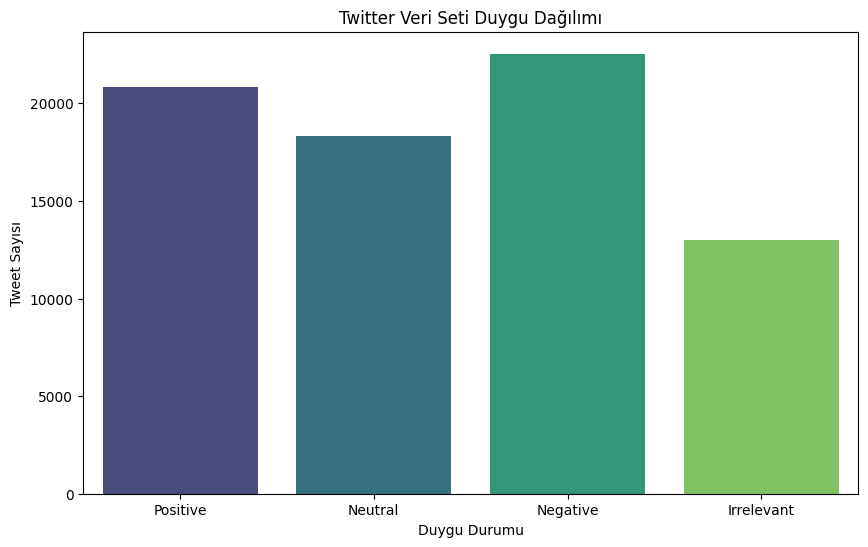

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='sentiment', palette='viridis')
plt.title('Twitter Veri Seti Duygu Dağılımı')
plt.xlabel('Duygu Durumu')
plt.ylabel('Tweet Sayısı')
plt.show()

### Belirli Bir Varlık (Entity) İçin Analiz
Veri setindeki 'Entity' sütununu kullanarak, örneğin 'Microsoft' veya 'Google' gibi markalar hakkındaki yorumları inceleyebiliriz.

In [15]:
entity_name = df_train['entity'].iloc[0] # İlk entity'yi seçelim
entity_df = df_train[df_train['entity'] == entity_name]

print(f"{entity_name} hakkındaki duygu dağılımı:")
print(entity_df['sentiment'].value_counts())

display(entity_df.head())

Borderlands hakkındaki duygu dağılımı:
sentiment
Positive      1020
Neutral        600
Negative       426
Irrelevant     240
Name: count, dtype: int64


,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [17]:
# Veri setindeki tüm benzersiz varlıkları (oyunlar, markalar vb.) listeleyelim
all_entities = sorted(df_train['entity'].unique())

print(f"Veri setinde toplam {len(all_entities)} farklı başlık bulunuyor:\n")
for entity in all_entities:
    print(f"- {entity}")

Veri setinde toplam 32 farklı başlık bulunuyor:

- Amazon
- ApexLegends
- AssassinsCreed
- Battlefield
- Borderlands
- CS-GO
- CallOfDuty
- CallOfDutyBlackopsColdWar
- Cyberpunk2077
- Dota2
- FIFA
- Facebook
- Fortnite
- Google
- GrandTheftAuto(GTA)
- Hearthstone
- HomeDepot
- LeagueOfLegends
- MaddenNFL
- Microsoft
- NBA2K
- Nvidia
- Overwatch
- PlayStation5(PS5)
- PlayerUnknownsBattlegrounds(PUBG)
- RedDeadRedemption(RDR)
- TomClancysGhostRecon
- TomClancysRainbowSix
- Verizon
- WorldOfCraft
- Xbox(Xseries)
- johnson&johnson


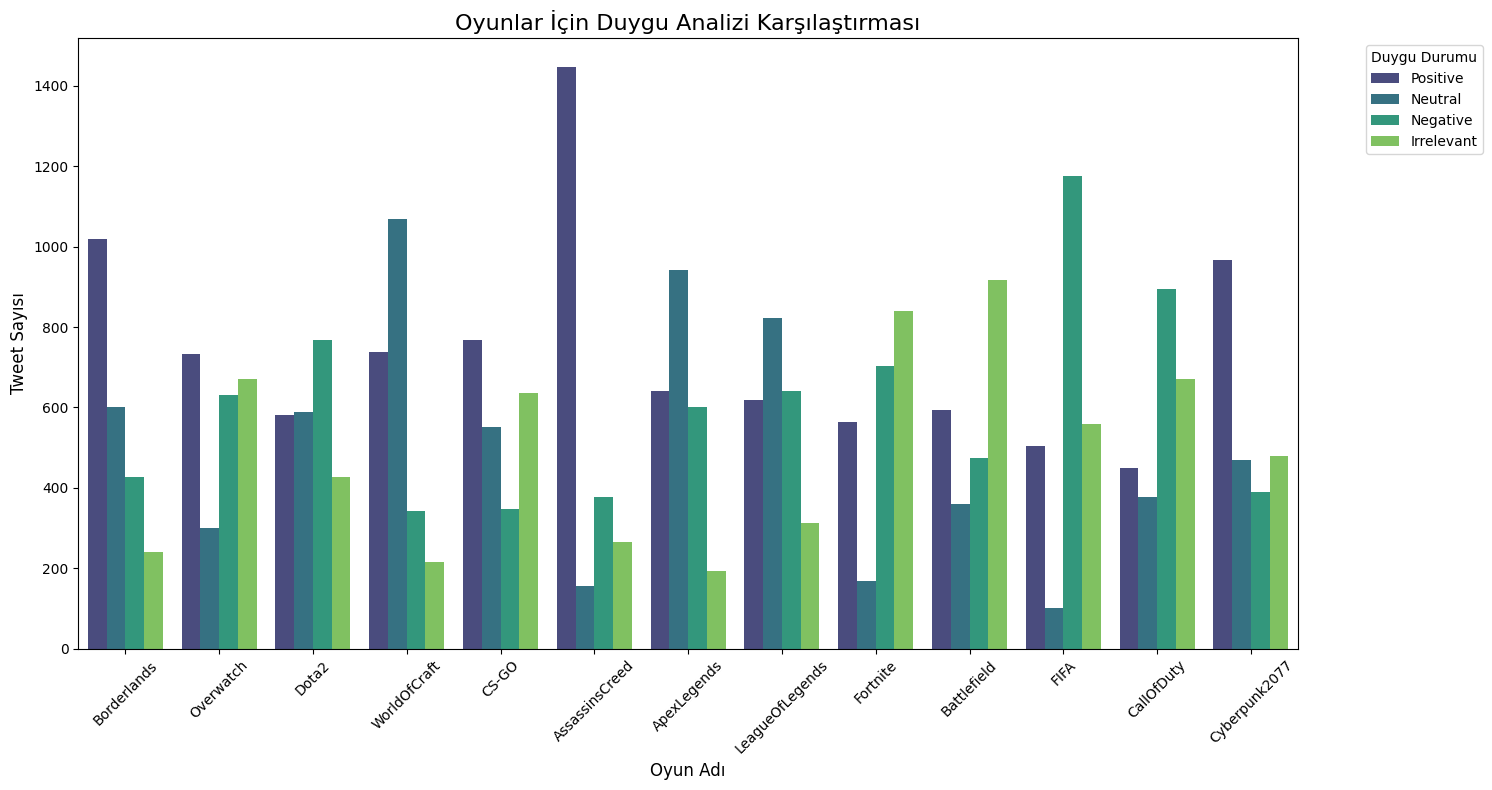

Oyun Bazlı Duygu Dağılımı Tablosu:


sentiment,Irrelevant,Negative,Neutral,Positive
entity,,,,
ApexLegends,192,600,942,642
AssassinsCreed,264,378,156,1446
Battlefield,918,474,360,594
Borderlands,240,426,600,1020
CS-GO,636,348,552,768
CallOfDuty,672,894,378,450
Cyberpunk2077,480,390,468,966
Dota2,426,768,588,582
FIFA,558,1176,102,504


In [18]:
# Oyunlarla ilgili entity'leri seçelim
games = [
    'ApexLegends', 'AssassinsCreed', 'Battlefield', 'Borderlands',
    'CS-GO', 'CallOfDuty', 'Cyberpunk2077', 'Dota2', 'FIFA',
    'Fortnite', 'LeagueOfLegends', 'Overwatch', 'WorldOfCraft'
]

# Oyun verilerini filtrele
df_games = df_train[df_train['entity'].isin(games)]

# Görselleştirme
plt.figure(figsize=(15, 8))
sns.countplot(data=df_games, x='entity', hue='sentiment', palette='viridis')

plt.title('Oyunlar İçin Duygu Analizi Karşılaştırması', fontsize=16)
plt.xticks(rotation=45)
plt.xlabel('Oyun Adı', fontsize=12)
plt.ylabel('Tweet Sayısı', fontsize=12)
plt.legend(title='Duygu Durumu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Özet tablo
print("Oyun Bazlı Duygu Dağılımı Tablosu:")
display(pd.crosstab(df_games['entity'], df_games['sentiment']))

### 1. Tweet Uzunluğu ve Duygu İlişkisi
Tweetlerin karakter uzunluğunun duygu durumuna göre nasıl değiştiğini inceleyelim.

/tmp/ipykernel_3499/4023983385.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='sentiment', y='text_length', palette='Set2')


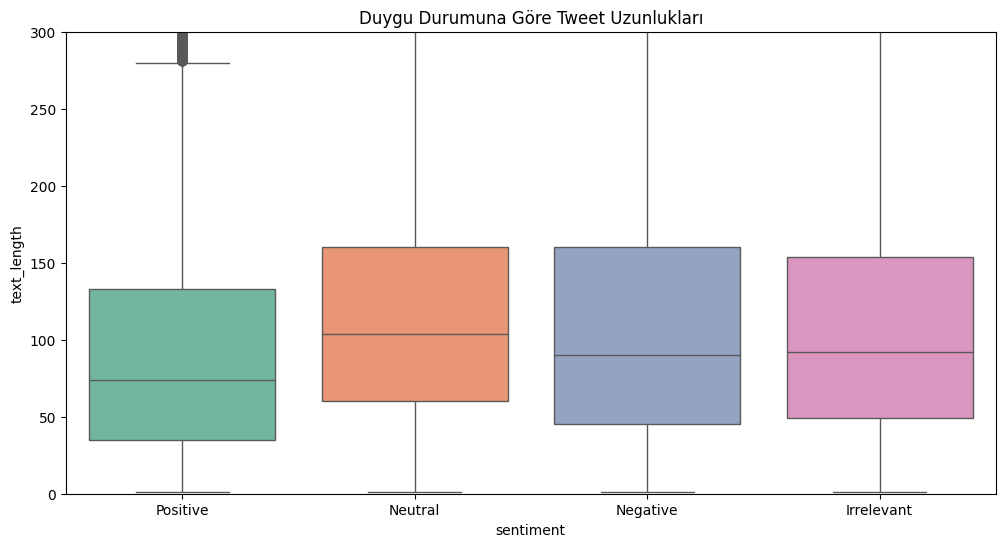

In [19]:
# Metin sütunundaki NaN değerleri temizleyelim ve uzunluk hesaplayalım
df_train['text_length'] = df_train['text'].astype(str).apply(len)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train, x='sentiment', y='text_length', palette='Set2')
plt.ylim(0, 300) # Çok uzun aykırı değerleri sınırlayalım
plt.title('Duygu Durumuna Göre Tweet Uzunlukları')
plt.show()

### 2. En Sık Geçen Kelimeler (Kelime Bulutu Hazırlığı)
Pozitif ve negatif tweetlerde en sık kullanılan kelimeleri karşılaştıralım.

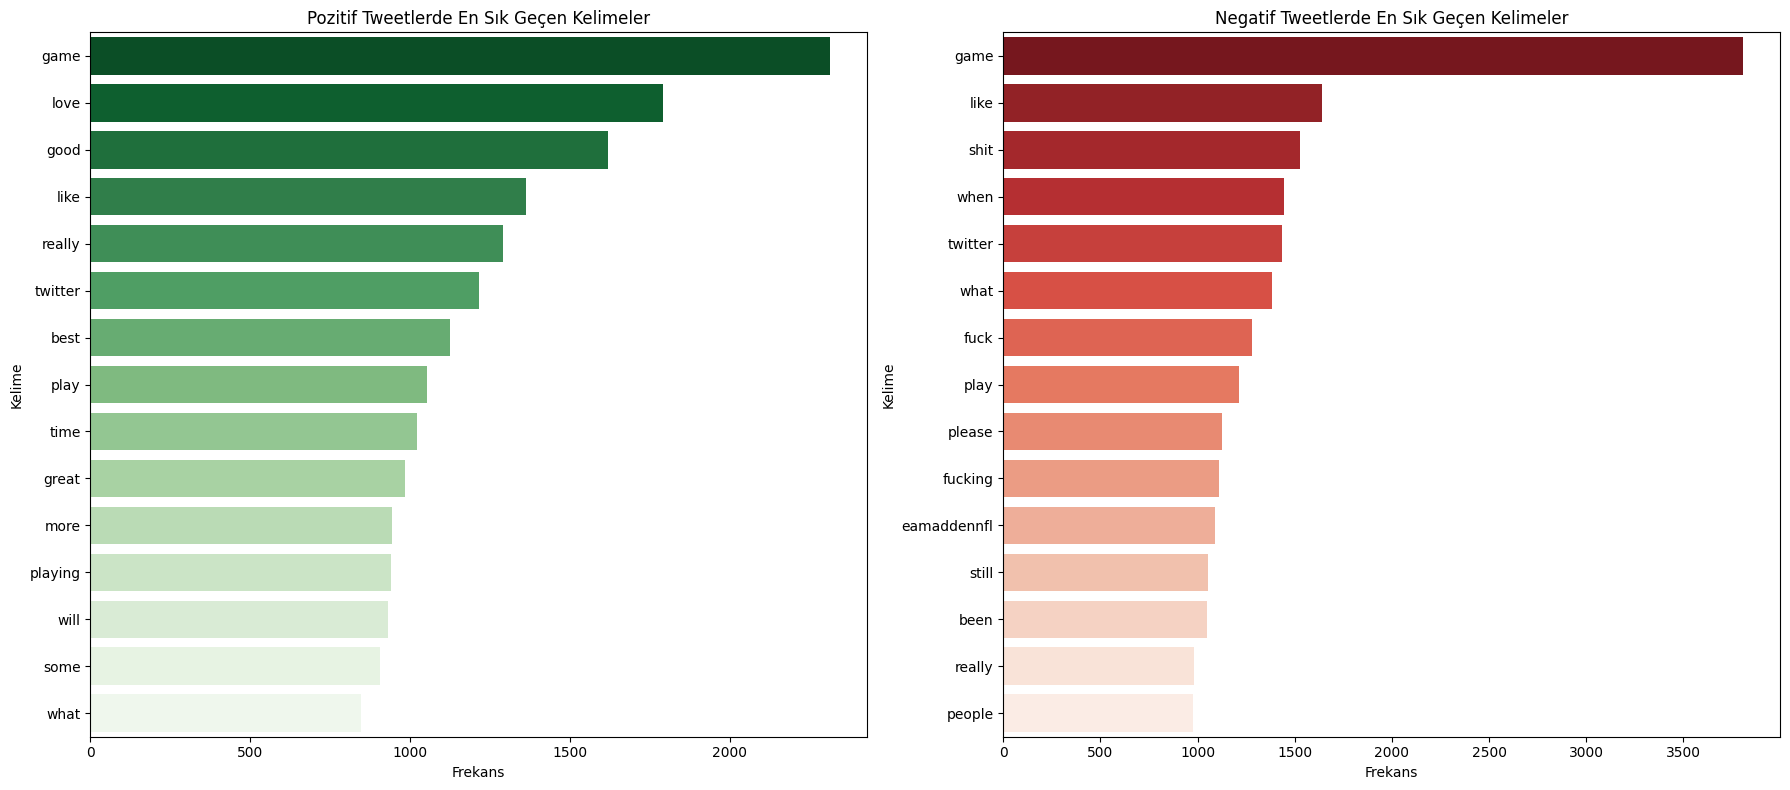

In [20]:
def get_most_common_words(sentiment_type, limit=15):
    # Belirli duygu tipindeki metinleri birleştir
    text = " ".join(df_train[df_train['sentiment'] == sentiment_type]['text'].astype(str).values.tolist())
    # Küçük harfe çevir ve kelimelere ayır
    words = re.findall(r'\w+', text.lower())
    # Yaygın kelimeleri ve kısa kelimeleri filtrele
    stop_words = {'this', 'that', 'with', 'have', 'just', 'your', 'they', 'from', 'about', 'here', 'there'}
    words = [w for w in words if len(w) > 3 and w not in stop_words]
    return Counter(words).most_common(limit)

# Verileri al
pos_words = get_most_common_words('Positive')
neg_words = get_most_common_words('Negative')

# DataFrame'e dönüştür
df_pos = pd.DataFrame(pos_words, columns=['Kelime', 'Frekans'])
df_neg = pd.DataFrame(neg_words, columns=['Kelime', 'Frekans'])

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pozitif Grafik - hue ve legend parametreleri eklendi
sns.barplot(data=df_pos, x='Frekans', y='Kelime', ax=axes[0], palette='Greens_r', hue='Kelime', legend=False)
axes[0].set_title('Pozitif Tweetlerde En Sık Geçen Kelimeler')

# Negatif Grafik - hue ve legend parametreleri eklendi
sns.barplot(data=df_neg, x='Frekans', y='Kelime', ax=axes[1], palette='Reds_r', hue='Kelime', legend=False)
axes[1].set_title('Negatif Tweetlerde En Sık Geçen Kelimeler')

plt.tight_layout()
plt.show()